In [ ]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [2]:
df = pd.read_csv("data/house_price.csv")

In [3]:
df

,Bedrooms,Bathrooms,Area_sqft,Location,Price
0,2,1.0,800.0,Urban,2500000.0
1,3,2.0,1200.0,Urban,4200000.0
2,4,3.0,1800.0,Urban,6500000.0
3,2,2.0,950.0,Suburban,2800000.0
4,3,2.0,1300.0,Suburban,4500000.0
...,...,...,...,...,...
95,2,1.0,800.0,Urban,2500000.0
96,2,1.0,800.0,urban,2500000.0
97,1,1.0,600.0,Rural,1800000.0
98,2,1.0,850.0,Rural,2200000.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Bedrooms   100 non-null    int64  
 1   Bathrooms  98 non-null     float64
 2   Area_sqft  96 non-null     float64
 3   Location   98 non-null     object 
 4   Price      98 non-null     float64
dtypes: float64(3), int64(1), object(1)
memory usage: 4.0+ KB


In [5]:
df.isnull().sum()

Bedrooms     0
Bathrooms    2
Area_sqft    4
Location     2
Price        2
dtype: int64

In [6]:
df['Bathrooms'] = df['Bathrooms'].fillna(df["Bathrooms"].median())
df['Area_sqft'] = df['Area_sqft'].fillna(df["Area_sqft"].median())
df['Price'] = df['Price'].fillna(df["Price"].median())

In [7]:
df.isnull().sum()

Bedrooms     0
Bathrooms    0
Area_sqft    0
Location     2
Price        0
dtype: int64

In [8]:
df["Location"].unique()

array(['Urban', 'Suburban', 'Rural', nan, 'urban', 'URBAN', ' suburban ',
       'RURAL'], dtype=object)

In [9]:
df["Location"] = df["Location"].fillna(df["Location"].mode()[0])

In [10]:
df["Location"] = df["Location"].astype(str)
df["Location"] = df["Location"].str.strip()
df["Location"] = df["Location"].str.title()


In [11]:
df["Location"].unique()

array(['Urban', 'Suburban', 'Rural'], dtype=object)

In [12]:
label = LabelEncoder()
df['Location'] = label.fit_transform(df['Location'])

In [13]:
df['Location'].unique()

array([2, 1, 0])

In [ ]:
X = df.drop(columns=["Price"])
y = df["Price"]

In [15]:
X

,Bedrooms,Bathrooms,Area_sqft,Location
0,2,1.0,800.0,2
1,3,2.0,1200.0,2
2,4,3.0,1800.0,2
3,2,2.0,950.0,1
4,3,2.0,1300.0,1
...,...,...,...,...
95,2,1.0,800.0,2
96,2,1.0,800.0,2
97,1,1.0,600.0,0
98,2,1.0,850.0,0


In [16]:
y

0     2500000.0
1     4200000.0
2     6500000.0
3     2800000.0
4     4500000.0
        ...    
95    2500000.0
96    2500000.0
97    1800000.0
98    2200000.0
99    4800000.0
Name: Price, Length: 100, dtype: float64

In [17]:
X_train, X_test , y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [18]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [19]:
X_train

array([[ 0.95202863,  0.94387981, -0.24255569,  0.92144268],
       [-0.79882862, -1.21355975, -0.87432865, -1.53573779],
       [ 1.82745726,  2.02259959,  2.10402958,  0.92144268],
       [ 0.95202863,  0.94387981,  0.84048367,  0.92144268],
       [ 0.07660001, -0.13483997,  0.11845743, -0.30714756],
       [ 0.95202863,  0.94387981,  1.20149679,  0.92144268],
       [-0.79882862, -1.21355975, -0.96458193,  0.92144268],
       [-0.79882862, -1.21355975, -0.96458193,  0.92144268],
       [ 0.07660001, -0.13483997,  0.11845743, -0.30714756],
       [ 0.95202863,  0.94387981,  0.84048367,  0.92144268],
       [ 0.07660001, -0.13483997, -0.24255569,  0.92144268],
       [-1.67425725, -1.21355975, -1.32559504, -1.53573779],
       [ 0.95202863,  0.94387981,  1.20149679,  0.92144268],
       [-0.79882862, -0.13483997, -0.87432865, -1.53573779],
       [-0.79882862, -0.13483997, -0.69382209, -0.30714756],
       [ 0.95202863,  0.94387981, -0.24255569,  0.92144268],
       [ 1.82745726,  2.

In [20]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [21]:
pred_val = model.predict(X_test)

In [22]:
pred_val

array([ 3237118.05674685,  3237118.05674685,  2364128.01143651,
        7041545.42147959,  4550499.02953054,  4686743.79897541,
        6752962.9651072 ,  2364128.01143651,  2364128.01143651,
        2364128.01143651,  2400064.56119366,  2364128.01143651,
        3237118.05674685,  3577729.98035903, 21710885.2726086 ,
        4550499.02953054,  9244009.35705626,  1222928.35785485,
        6769055.88258984,  4430347.17756831])

In [25]:
df.columns

Index(['Bedrooms', 'Bathrooms', 'Area_sqft', 'Location', 'Price'], dtype='object')

In [26]:
df.head(1)

,Bedrooms,Bathrooms,Area_sqft,Location,Price
0,2,1.0,800.0,2,2500000.0


In [27]:
new_val = [[3, 3.0, 500, 1]]

new_price = scaler.transform(new_val)

e:\ML\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [28]:
pred_price = model.predict(new_price)
print('The new price will be: ',  pred_price)

The new price will be:  [4145256.68259721]


In [29]:
from sklearn.metrics import r2_score

score = r2_score(y_test, pred_val)

print(score)

0.5205311757297881


In [ ]:
print("Train Score:", model.score(X_train, y_train))
print("Test Score :", model.score(X_test, y_test))

Train Score: 0.9779332795007255
Test Score : 0.5205311757297881


In [32]:
def print_num(n):
    if n == 6:
        return
    print(n)
    print_num(n+1)
print_num(1)

1
2
3
4
5


In [33]:
def new(n):
    if n == 1:
        return 
    print(n)
    return new(n-1)
new(5)

5
4
3
2


In [34]:
def fact(n):
    if n == 1:
        return 1
    return n * fact(n-1)
print(fact(5))

120


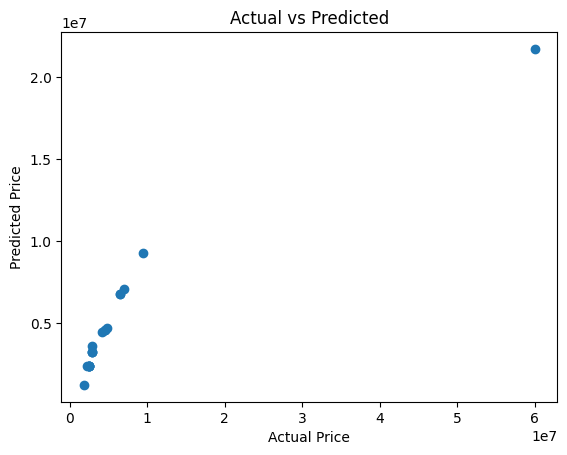

In [35]:
import matplotlib.pyplot as plt
plt.scatter(y_test, pred_val)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")

plt.show()